# Analyse des Facteurs Influençant le Rendement des Cultures Agricoles

## Contexte
**Entreprise :** Coopérative agricole InVivo  
**Binôme :** Aboubacar Sidiki YATTARA et Dissirama GOMNAH

Nous intervenons en tant que Data Analysts pour la coopérative InVivo.
Cette analyse vise à identifier les facteurs climatiques et environnementaux qui influencent la productivité agricole, afin d'améliorer les recommandations aux agriculteurs et augmenter les rendements de manière durable.

## Problématiques
- Quels pays et régions ont les meilleurs rendements ?
- Comment la pluviométrie et la température affectent-elles les cultures ?
- Quelles cultures sont les plus sensibles aux pesticides ?

## Source des données
**Dataset :** Crop Yield Prediction Dataset — Kaggle  
**Période :** 1990 – 2013 (23 ans de données historiques)  
28 242 observations | 7 variables | 101 pays | 10 cultures

## 1. Chargement des bibliothèques

In [1]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Bibliothèques chargées")

Bibliothèques chargées


## 2. Chargement et audit du dataset

In [3]:
# Chargement du dataset fusionné
df = pd.read_csv('yield_df.csv')

# Suppression de la colonne d'index inutile
df = df.drop(columns=['Unnamed: 0'])

# Audit
print("=== APERÇU DU DATASET ===")
print(df.head())

print("\n=== DIMENSIONS ===")
print(f"Lignes : {df.shape[0]} | Colonnes : {df.shape[1]}")

print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

print("\n=== INFORMATIONS GÉNÉRALES ===")
print(f"Pays couverts  : {df['Area'].nunique()}")
print(f"Cultures       : {df['Item'].nunique()} -- {sorted(df['Item'].unique())}")
print(f"Période        : {df['Year'].min()} -- {df['Year'].max()}")

print("\n Dataset: aucune valeur manquante")

=== APERÇU DU DATASET ===
      Area         Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
0  Albania        Maize  1990        36613                         1485.0   
1  Albania     Potatoes  1990        66667                         1485.0   
2  Albania  Rice, paddy  1990        23333                         1485.0   
3  Albania      Sorghum  1990        12500                         1485.0   
4  Albania     Soybeans  1990         7000                         1485.0   

   pesticides_tonnes  avg_temp  
0              121.0     16.37  
1              121.0     16.37  
2              121.0     16.37  
3              121.0     16.37  
4              121.0     16.37  

=== DIMENSIONS ===
Lignes : 28242 | Colonnes : 7

=== VALEURS MANQUANTES ===
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                 

## 3. Nettoyage des données

In [4]:
# ============================================================
# Nettoyage des données
# ============================================================

# --- Vérification des valeurs manquantes ---
print("=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

# --- Détection des outliers via la méthode IQR ---
print("\n=== DÉTECTION DES OUTLIERS (méthode IQR) ===")
for col in ['hg/ha_yield', 'pesticides_tonnes', 'avg_temp', 'average_rain_fall_mm_per_year']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col} : {len(outliers)} outliers détectés")

print("\nOutliers conservés — ils représentent des réalités géographiques réelles")

# --- Suppression des doublons ---
print(f"\n=== DOUBLONS ===")
print(f"Doublons détectés : {df.duplicated().sum()}")
print("Exemple de doublons (même pays, même culture, même année) :")
print(df[df.duplicated(keep=False)].sort_values(['Area','Item','Year']).head(4))

df = df.drop_duplicates()

# --- Bilan final ---
print("\n=== BILAN DU NETTOYAGE ===")
print(f"Lignes avant nettoyage  : 28 242")
print(f"Doublons supprimés      : 2 310")
print(f"Lignes après nettoyage  : {df.shape[0]}")
print(f"Valeurs manquantes      : 0")
print(f"\nDataset final prêt pour l'analyse : {df.shape[0]} lignes × {df.shape[1]} colonnes")

=== VALEURS MANQUANTES ===
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

=== DÉTECTION DES OUTLIERS (méthode IQR) ===
hg/ha_yield : 2059 outliers détectés
pesticides_tonnes : 1418 outliers détectés
avg_temp : 34 outliers détectés
average_rain_fall_mm_per_year : 0 outliers détectés

Outliers conservés — ils représentent des réalités géographiques réelles

=== DOUBLONS ===
Doublons détectés : 2310
Exemple de doublons (même pays, même culture, même année) :
            Area   Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
2082  Bangladesh  Maize  1990        10015                         2666.0   
2083  Bangladesh  Maize  1990        10015                         2666.0   
2094  Bangladesh  Maize  1991         9781                         2666.0   
2095  Bangladesh  Ma

## 4. Statistiques descriptives

=== RENDEMENT MOYEN PAR CULTURE (hg/ha) ===
                       Moyenne  Minimum  Maximum  Écart-type
Item                                                        
Potatoes              198666.0     8406   501412     94200.0
Cassava               145650.0    11778   385818     88461.0
Sweet potatoes        119657.0     8799   400000     71587.0
Yams                  112106.0    11475   250000     53331.0
Plantains and others  106041.0    21350   418505     72128.0
Rice, paddy            41296.0     2034   103895     19648.0
Maize                  37139.0      849   207556     28172.0
Wheat                  30126.0     1706    99387     18641.0
Sorghum                19100.0      578   206000     15492.0
Soybeans               16992.0       50    41609      7694.0


/tmp/ipykernel_84491/4028379685.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Item', y='hg/ha_yield', order=ordre, palette='Blues_d', ax=axes[0])
/tmp/ipykernel_84491/4028379685.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(ordre, rotation=40, ha='right')


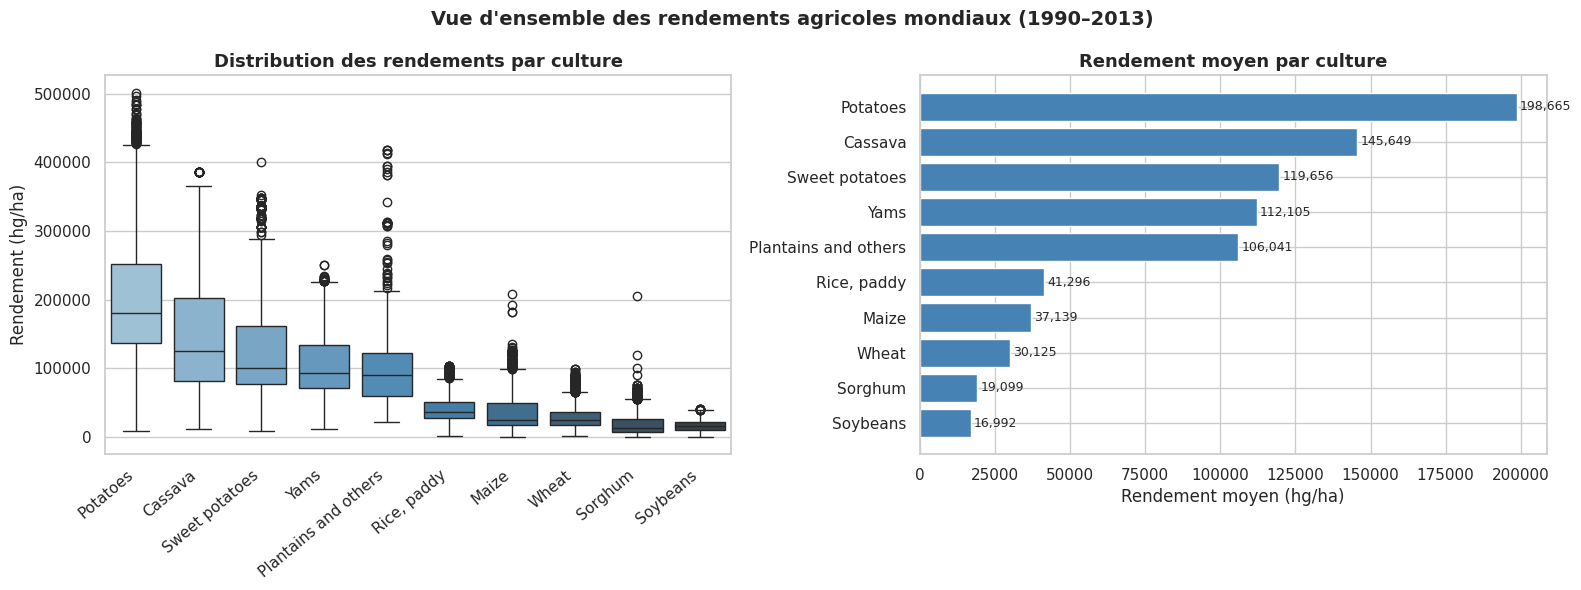

In [5]:
# Statistiques par culture
stats_culture = (
    df.groupby('Item')['hg/ha_yield']
    .agg(['mean', 'min', 'max', 'std'])
    .round(0)
    .sort_values('mean', ascending=False)
)
stats_culture.columns = ['Moyenne', 'Minimum', 'Maximum', 'Écart-type']
print("=== RENDEMENT MOYEN PAR CULTURE (hg/ha) ===")
print(stats_culture)

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
ordre = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='Item', y='hg/ha_yield', order=ordre, palette='Blues_d', ax=axes[0])
axes[0].set_xticklabels(ordre, rotation=40, ha='right')
axes[0].set_title('Distribution des rendements par culture', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Rendement (hg/ha)')

# Barplot
moyennes = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)
axes[1].barh(moyennes.index[::-1], moyennes.values[::-1], color='steelblue')
axes[1].set_title('Rendement moyen par culture', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rendement moyen (hg/ha)')
for i, v in enumerate(moyennes.values[::-1]):
    axes[1].text(v + 1000, i, f'{int(v):,}', va='center', fontsize=9)

plt.suptitle("Vue d'ensemble des rendements agricoles mondiaux (1990–2013)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('stats_rendements.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analyse : Impact des pesticides sur le rendement

Corrélation globale pesticides -- rendement : 0.07

=== CORRÉLATION PAR CULTURE ===
Item
Soybeans                0.35
Potatoes                0.21
Sorghum                 0.20
Cassava                 0.15
Sweet potatoes          0.15
Rice, paddy             0.11
Maize                   0.09
Yams                    0.01
Wheat                  -0.04
Plantains and others   -0.05
Name: hg/ha_yield, dtype: float64


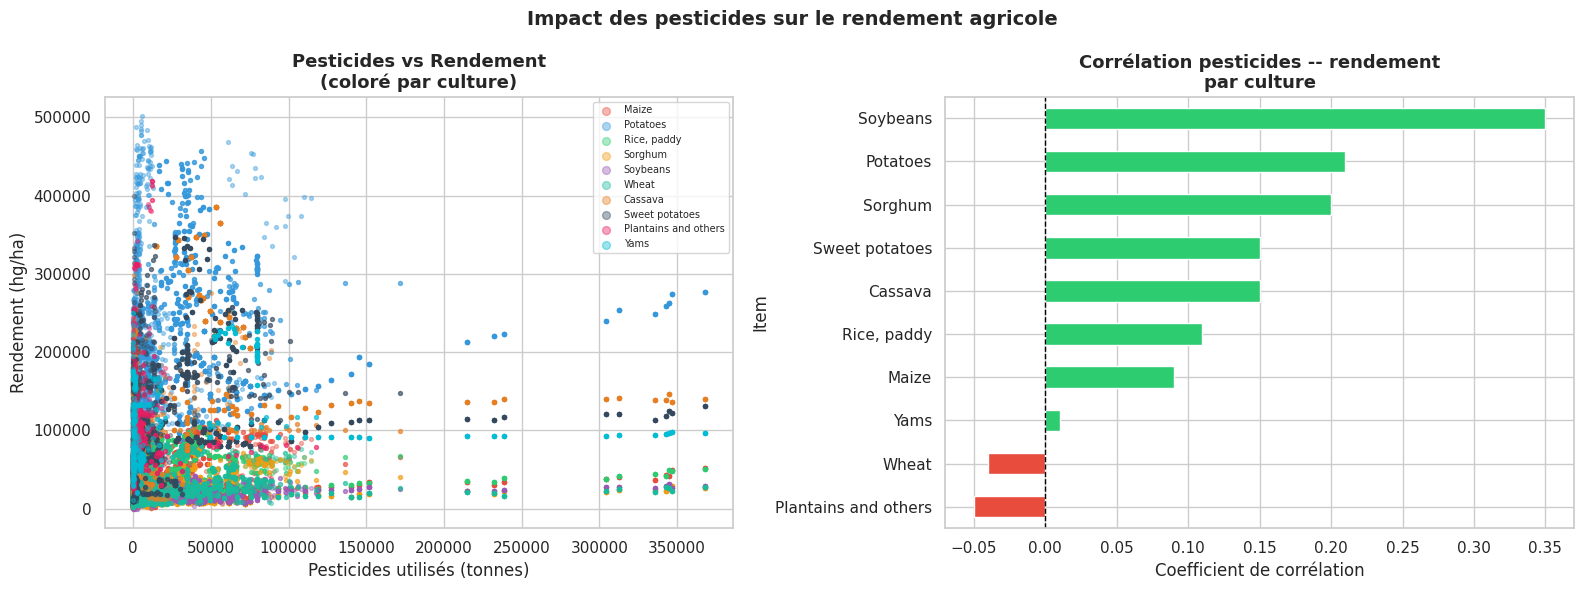


CONCLUSION :
Corrélation globale de 0.07 -- lien positif modéré entre pesticides et rendement.
Certaines cultures bénéficient plus que d'autres des pesticides.


In [6]:
# ============================================================
# Analyse : Impact des pesticides sur le rendement
# ============================================================

# Corrélation globale
corr = df['pesticides_tonnes'].corr(df['hg/ha_yield'])
print(f"Corrélation globale pesticides -- rendement : {corr:.2f}")

# Corrélation par culture
print("\n=== CORRÉLATION PAR CULTURE ===")
corr_culture = (
    df.groupby('Item')[['pesticides_tonnes', 'hg/ha_yield']]
    .corr()
    .unstack()
    ['pesticides_tonnes']['hg/ha_yield']
    .sort_values(ascending=False)
    .round(2)
)
print(corr_culture)

# Visualisation 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter par culture
cultures = df['Item'].unique()
palette = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6',
           '#1ABC9C','#E67E22','#34495E','#E91E63','#00BCD4']

for i, culture in enumerate(cultures):
    subset = df[df['Item'] == culture]
    axes[0].scatter(subset['pesticides_tonnes'], subset['hg/ha_yield'],
                    alpha=0.4, s=8, color=palette[i], label=culture)

axes[0].set_title('Pesticides vs Rendement\n(coloré par culture)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pesticides utilisés (tonnes)')
axes[0].set_ylabel('Rendement (hg/ha)')
axes[0].legend(fontsize=7, markerscale=2, loc='upper right')

# Corrélation par culture barplot
corr_culture.sort_values().plot(kind='barh', ax=axes[1],
                                 color=['#E74C3C' if v < 0 else '#2ECC71' 
                                        for v in corr_culture.sort_values()])
axes[1].set_title('Corrélation pesticides -- rendement\npar culture',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coefficient de corrélation')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.suptitle("Impact des pesticides sur le rendement agricole",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('analyse_pesticides.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCONCLUSION :")
print(f"Corrélation globale de {corr:.2f} -- lien positif modéré entre pesticides et rendement.")
print("Certaines cultures bénéficient plus que d'autres des pesticides.")

## 6. Comparaison géographique — Top/Flop pays

=== TOP 10 PAYS (rendement moyen) ===
Area
United Kingdom    240956.0
Belgium           216468.0
Denmark           214033.0
Netherlands       204151.0
Ireland           197914.0
New Zealand       191932.0
Sweden            187406.0
Bahrain           153238.0
Norway            146115.0
Switzerland       144960.0
Name: hg/ha_yield, dtype: float64

=== FLOP 10 PAYS (rendement moyen) ===
Area
Nepal                       35771.0
Angola                      34894.0
Ecuador                     34325.0
Burundi                     33967.0
Madagascar                  33171.0
Burkina Faso                33062.0
Mauritania                  27738.0
Central African Republic    26432.0
Eritrea                     18155.0
Botswana                     7354.0
Name: hg/ha_yield, dtype: float64


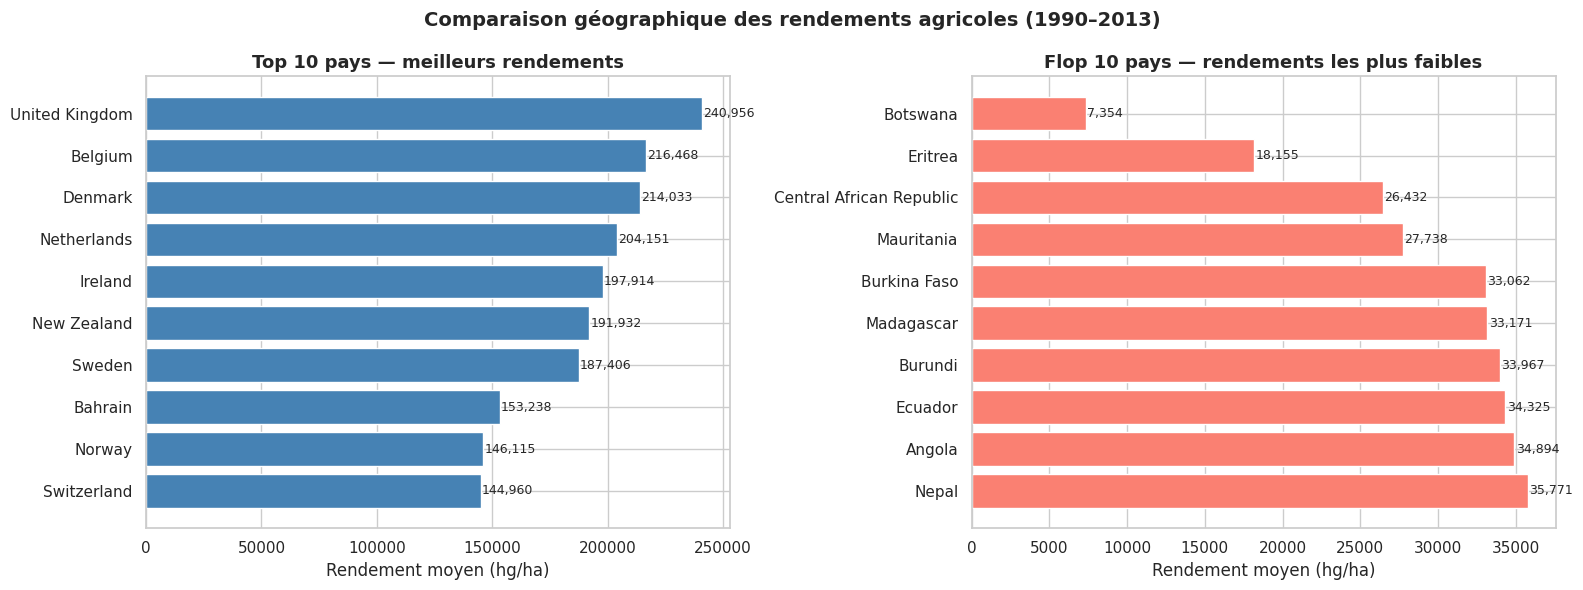


=== MEILLEUR PAYS PAR CULTURE ===
                     Meilleur pays  Rendement moyen
Item                                               
Cassava                      India         282958.0
Maize                        Qatar         136593.0
Plantains and others     Guatemala         291096.0
Potatoes                   Belgium         448892.0
Rice, paddy                  Egypt          89235.0
Sorghum                    Austria          63873.0
Soybeans                     Italy          34447.0
Sweet potatoes               Egypt         261369.0
Wheat                      Belgium          84989.0
Yams                         Japan         210898.0

CONCLUSION :
Le pays le plus productif est : United Kingdom (240,956 hg/ha)
Le pays le moins productif est : Botswana (7,354 hg/ha)


In [7]:
# ============================================================
# Analyse : Comparaison géographique top/flop pays
# ============================================================

# ---Rendement moyen par pays (toutes cultures confondues) ---
rendement_pays = (
    df.groupby('Area')['hg/ha_yield']
    .mean()
    .sort_values(ascending=False)
    .round(0)
)

print("=== TOP 10 PAYS (rendement moyen) ===")
print(rendement_pays.head(10))
print("\n=== FLOP 10 PAYS (rendement moyen) ===")
print(rendement_pays.tail(10))

# ---Visualisation Top/Flop ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10
top10 = rendement_pays.head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color='steelblue')
axes[0].set_title('Top 10 pays — meilleurs rendements', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rendement moyen (hg/ha)')
for i, v in enumerate(top10.values[::-1]):
    axes[0].text(v + 500, i, f'{int(v):,}', va='center', fontsize=9)

# Flop 10
flop10 = rendement_pays.tail(10)
axes[1].barh(flop10.index, flop10.values, color='salmon')
axes[1].set_title('Flop 10 pays — rendements les plus faibles', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rendement moyen (hg/ha)')
for i, v in enumerate(flop10.values):
    axes[1].text(v + 100, i, f'{int(v):,}', va='center', fontsize=9)

plt.suptitle("Comparaison géographique des rendements agricoles (1990–2013)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_geographique.png', dpi=150, bbox_inches='tight')
plt.show()

# ---Top pays par culture ---
print("\n=== MEILLEUR PAYS PAR CULTURE ===")
top_par_culture = (
    df.groupby(['Item', 'Area'])['hg/ha_yield']
    .mean()
    .reset_index()
    .sort_values('hg/ha_yield', ascending=False)
    .groupby('Item')
    .first()
    [['Area', 'hg/ha_yield']]
    .round(0)
)
top_par_culture.columns = ['Meilleur pays', 'Rendement moyen']
print(top_par_culture)

print("\nCONCLUSION :")
print(f"Le pays le plus productif est : {rendement_pays.index[0]} ({int(rendement_pays.iloc[0]):,} hg/ha)")
print(f"Le pays le moins productif est : {rendement_pays.index[-1]} ({int(rendement_pays.iloc[-1]):,} hg/ha)")

## 7. Clustering K-means — Segmentation des pays

Nombre de pays : 101


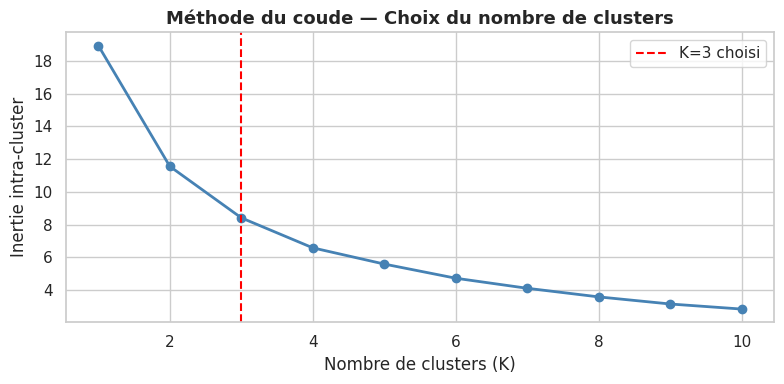


=== PROFIL MOYEN PAR CLUSTER ===
         hg/ha_yield  avg_temp  pesticides_tonnes  \
cluster                                             
0            71718.0      25.0            17042.0   
1            58626.0      22.0             6351.0   
2           109266.0      10.0            16781.0   

         average_rain_fall_mm_per_year  
cluster                                 
0                               2104.0  
1                                700.0  
2                                820.0  


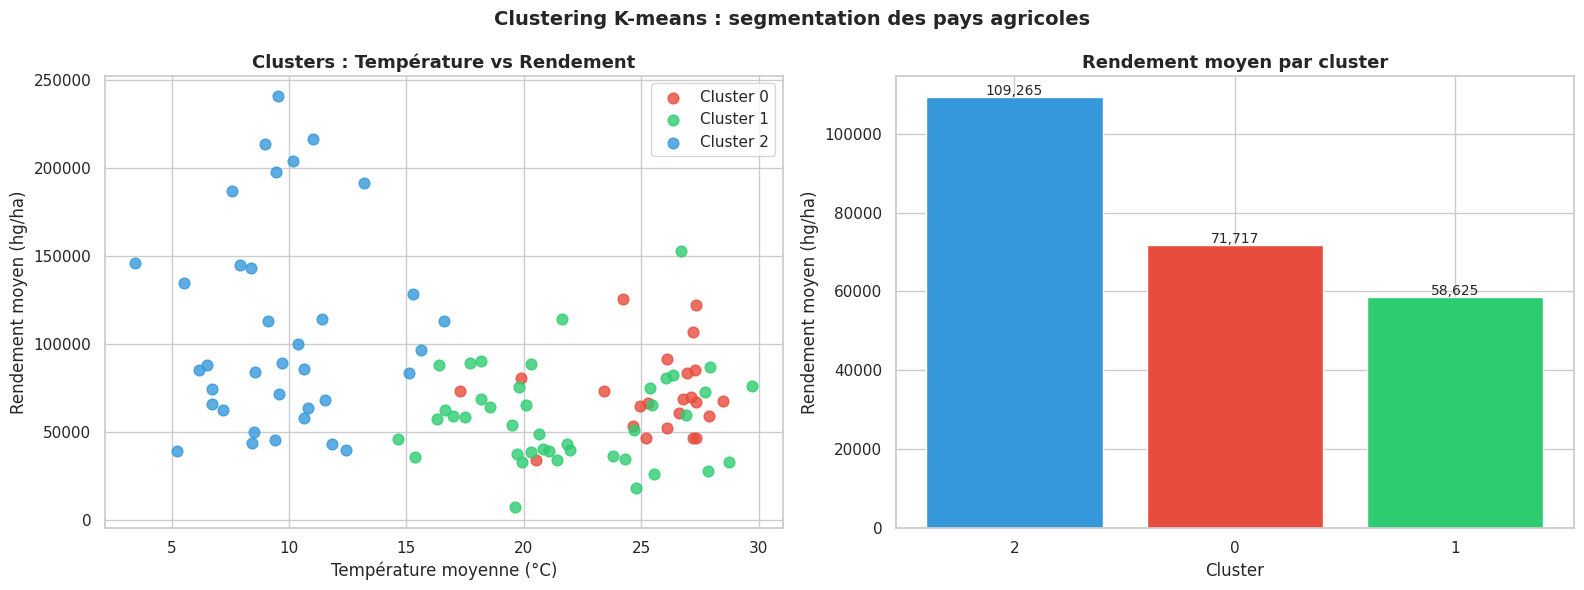


=== PAYS DU CLUSTER AUX MEILLEURS RENDEMENTS ===
['Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Belarus', 'Belgium', 'Bulgaria', 'Canada', 'Chile', 'Croatia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Hungary', 'Ireland', 'Italy', 'Japan', 'Kazakhstan', 'Latvia', 'Lithuania', 'Montenegro', 'Netherlands', 'New Zealand', 'Norway', 'Poland', 'Romania', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Tajikistan', 'Turkey', 'Ukraine', 'United Kingdom']

CONCLUSION : 3 groupes distincts identifiés
Les pays à forts rendements sont majoritairement des pays européens à climat froid
Les pays à faibles rendements sont majoritairement des pays africains à climat chaud


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# --- Agrégation par pays ---
df_pays = df.groupby('Area')[['hg/ha_yield', 'average_rain_fall_mm_per_year',
                               'pesticides_tonnes', 'avg_temp']].mean().reset_index()

print(f"Nombre de pays : {df_pays.shape[0]}")

# --- Normalisation min/max ---
scaler = MinMaxScaler()
X = scaler.fit_transform(df_pays[['hg/ha_yield', 'average_rain_fall_mm_per_year',
                                   'pesticides_tonnes', 'avg_temp']])

# --- Méthode du coude ---
inerties = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inerties.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inerties, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', label='K=3 choisi')
plt.title('Méthode du coude — Choix du nombre de clusters', fontsize=13, fontweight='bold')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie intra-cluster')
plt.legend()
plt.tight_layout()
plt.savefig('methode_coude.png', dpi=150, bbox_inches='tight')
plt.show()

# --- K-means K=3 ---
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pays['cluster'] = km3.fit_predict(X)

# --- Profil des clusters ---
print("\n=== PROFIL MOYEN PAR CLUSTER ===")
profils = df_pays.groupby('cluster')[['hg/ha_yield', 'avg_temp',
                                       'pesticides_tonnes',
                                       'average_rain_fall_mm_per_year']].mean().round(0)
print(profils)

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
couleurs = {0: '#E74C3C', 1: '#2ECC71', 2: '#3498DB'}

for c in sorted(df_pays['cluster'].unique()):
    subset = df_pays[df_pays['cluster'] == c]
    axes[0].scatter(subset['avg_temp'], subset['hg/ha_yield'],
                    c=couleurs[c], label=f'Cluster {c}', s=60, alpha=0.8)

axes[0].set_title('Clusters : Température vs Rendement', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Température moyenne (°C)')
axes[0].set_ylabel('Rendement moyen (hg/ha)')
axes[0].legend()

rendement_cluster = df_pays.groupby('cluster')['hg/ha_yield'].mean().sort_values(ascending=False)
bars = axes[1].bar(rendement_cluster.index.astype(str),
                   rendement_cluster.values,
                   color=[couleurs[i] for i in rendement_cluster.index])
axes[1].set_title('Rendement moyen par cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Rendement moyen (hg/ha)')
for bar, val in zip(bars, rendement_cluster.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 500,
                 f'{int(val):,}', ha='center', fontsize=10)

plt.suptitle("Clustering K-means : segmentation des pays agricoles",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== PAYS DU CLUSTER AUX MEILLEURS RENDEMENTS ===")
meilleur = rendement_cluster.index[0]
print(list(df_pays[df_pays['cluster'] == meilleur]['Area'].values))

print("\nCONCLUSION : 3 groupes distincts identifiés")
print("Les pays à forts rendements sont majoritairement des pays européens à climat froid")
print("Les pays à faibles rendements sont majoritairement des pays africains à climat chaud")

## 8. Analyse : Impact du climat sur le rendement

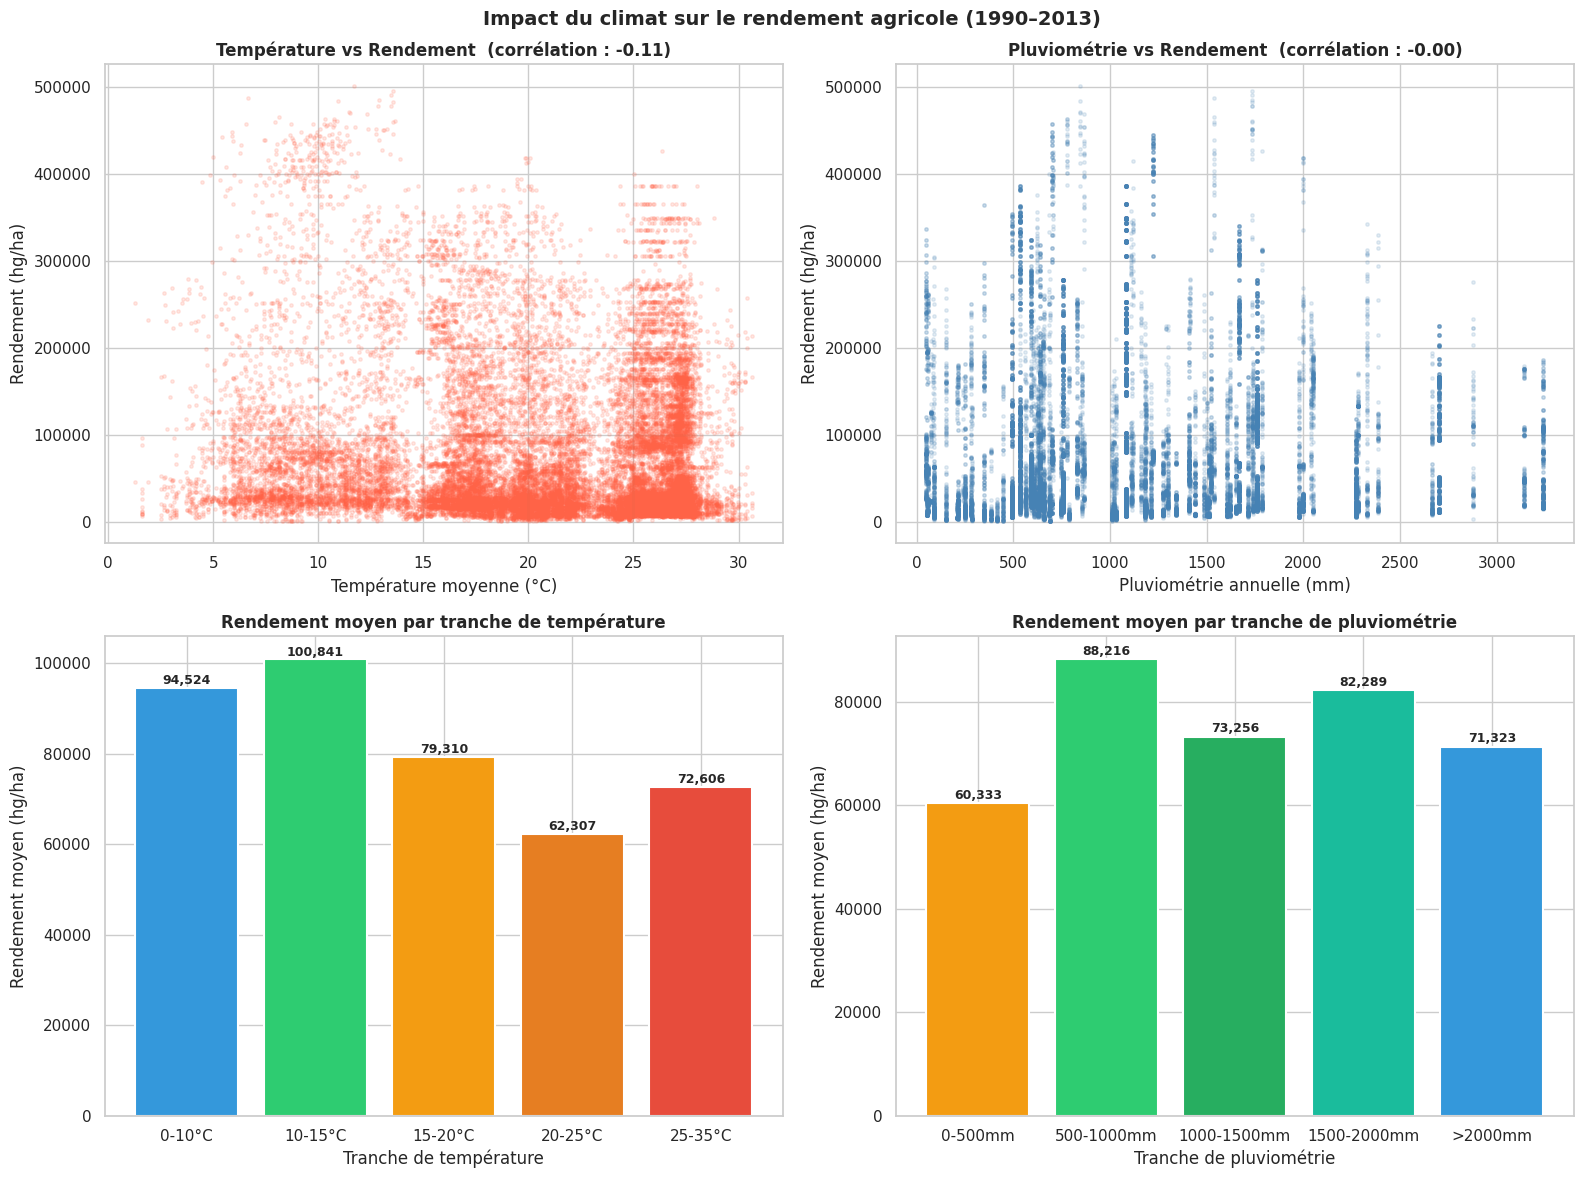

=== CORRÉLATIONS CLIMATIQUES ===
Température à rendement  : -0.11
Pluviométrie à rendement : -0.00

CONCLUSION :
Les pays avec des températures entre 0-10°C ont les meilleurs rendements.
L'impact de la pluviométrie est moins marqué que celui de la température.


In [9]:
# ============================================================
# Analyse : Impact du climat sur le rendement
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Graphique 1 : Scatter température vs rendement ---
corr_temp = df['avg_temp'].corr(df['hg/ha_yield'])
axes[0,0].scatter(df['avg_temp'], df['hg/ha_yield'],
                  alpha=0.15, color='tomato', s=6)
axes[0,0].set_title(f'Température vs Rendement  (corrélation : {corr_temp:.2f})',
                    fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Température moyenne (°C)')
axes[0,0].set_ylabel('Rendement (hg/ha)')

# --- Graphique 2 : Scatter pluviométrie vs rendement ---
corr_pluie = df['average_rain_fall_mm_per_year'].corr(df['hg/ha_yield'])
axes[0,1].scatter(df['average_rain_fall_mm_per_year'], df['hg/ha_yield'],
                  alpha=0.15, color='steelblue', s=6)
axes[0,1].set_title(f'Pluviométrie vs Rendement  (corrélation : {corr_pluie:.2f})',
                    fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Pluviométrie annuelle (mm)')
axes[0,1].set_ylabel('Rendement (hg/ha)')

# --- Graphique 3 : Barplot température par tranches ---
df['tranche_temp'] = pd.cut(df['avg_temp'],
                             bins=[0, 10, 15, 20, 25, 35],
                             labels=['0-10°C', '10-15°C', '15-20°C', '20-25°C', '25-35°C'])
rend_temp = df.groupby('tranche_temp', observed=False)['hg/ha_yield'].mean().round(0)

couleurs_temp = ['#3498DB', '#2ECC71', '#F39C12', '#E67E22', '#E74C3C']
bars1 = axes[1,0].bar(rend_temp.index, rend_temp.values,
                      color=couleurs_temp, edgecolor='white', linewidth=1.5)
axes[1,0].set_title('Rendement moyen par tranche de température',
                    fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Tranche de température')
axes[1,0].set_ylabel('Rendement moyen (hg/ha)')
for bar, val in zip(bars1, rend_temp.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, val + 800,
                   f'{int(val):,}', ha='center', fontsize=9, fontweight='bold')

# --- Graphique 4 : Barplot pluviométrie par tranches ---
df['tranche_pluie'] = pd.cut(df['average_rain_fall_mm_per_year'],
                              bins=[0, 500, 1000, 1500, 2000, 4000],
                              labels=['0-500mm', '500-1000mm', '1000-1500mm',
                                      '1500-2000mm', '>2000mm'])
rend_pluie = df.groupby('tranche_pluie', observed=False)['hg/ha_yield'].mean().round(0)

couleurs_pluie = ['#F39C12', '#2ECC71', '#27AE60', '#1ABC9C', '#3498DB']
bars2 = axes[1,1].bar(rend_pluie.index, rend_pluie.values,
                      color=couleurs_pluie, edgecolor='white', linewidth=1.5)
axes[1,1].set_title('Rendement moyen par tranche de pluviométrie',
                    fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Tranche de pluviométrie')
axes[1,1].set_ylabel('Rendement moyen (hg/ha)')
for bar, val in zip(bars2, rend_pluie.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, val + 800,
                   f'{int(val):,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f"Impact du climat sur le rendement agricole (1990–2013)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('impact_climat.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== CORRÉLATIONS CLIMATIQUES ===")
print(f"Température à rendement  : {corr_temp:.2f}")
print(f"Pluviométrie à rendement : {corr_pluie:.2f}")
print("\nCONCLUSION :")
print("Les pays avec des températures entre 0-10°C ont les meilleurs rendements.")
print("L'impact de la pluviométrie est moins marqué que celui de la température.")

## 9. Évolution temporelle des rendements (1990–2013)

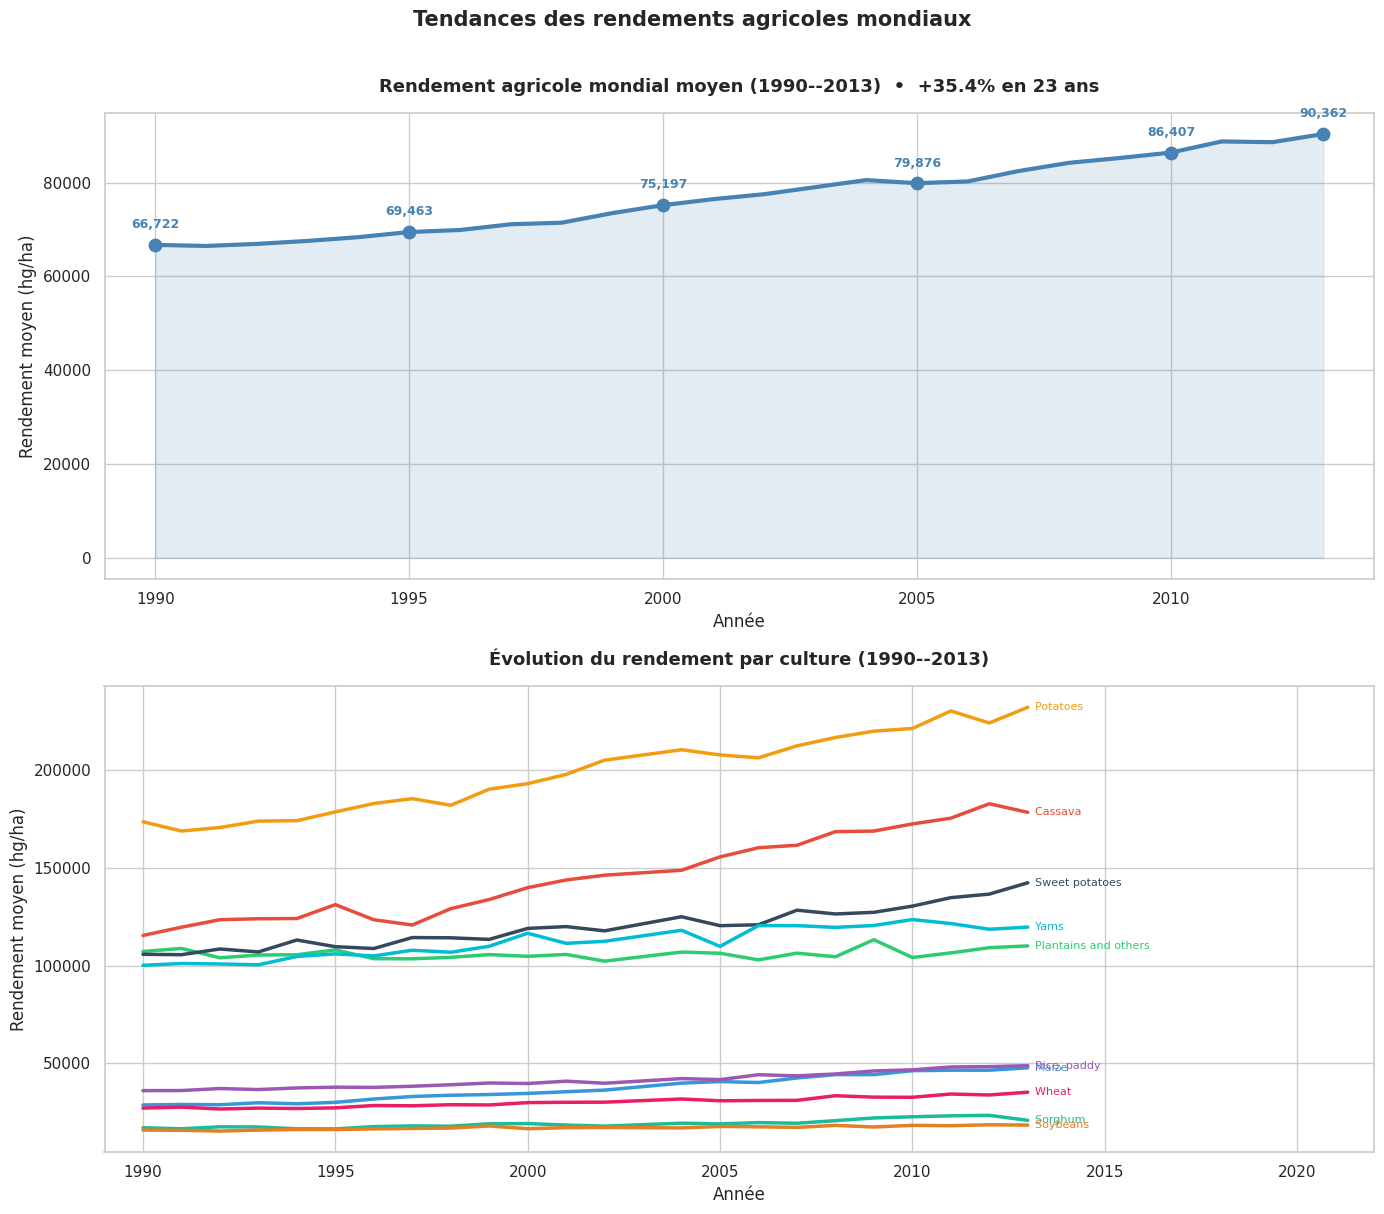

=== ÉVOLUTION DES RENDEMENTS ===
Rendement moyen en 1990 : 66,722 hg/ha
Rendement moyen en 2013 : 90,362 hg/ha
Progression             : +35.4% en 23 ans

CONCLUSION :
Les rendements ont progressé de 35.4% en 23 ans.
Les pommes de terre et le manioc dominent largement toutes les autres cultures.


In [10]:
# ============================================================
# Analyse : Évolution temporelle des rendements 1990--2013
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- Graphique 1 : Évolution globale avec annotations ---
evolution = df.groupby('Year')['hg/ha_yield'].mean().round(0)

axes[0].fill_between(evolution.index, evolution.values,
                     alpha=0.15, color='steelblue')
axes[0].plot(evolution.index, evolution.values,
             color='steelblue', linewidth=3)

# Points clés annotés
for year in [1990, 1995, 2000, 2005, 2010, 2013]:
    val = int(evolution[year])
    axes[0].scatter(year, val, color='steelblue', s=80, zorder=5)
    axes[0].annotate(f'{val:,}',
                     xy=(year, val),
                     xytext=(0, 12),
                     textcoords='offset points',
                     ha='center', fontsize=9,
                     fontweight='bold', color='steelblue')

rend_1990 = int(evolution[1990])
rend_2013 = int(evolution[2013])
progression = round(((rend_2013 - rend_1990) / rend_1990) * 100, 1)

axes[0].set_title(f'Rendement agricole mondial moyen (1990--2013)  •  +{progression}% en 23 ans',
                  fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Rendement moyen (hg/ha)')
axes[0].set_xlim(1989, 2014)

# --- Graphique 2 : Évolution par culture ---
evolution_culture = df.groupby(['Year', 'Item'])['hg/ha_yield'].mean().unstack()

palette = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6',
           '#1ABC9C','#E67E22','#34495E','#E91E63','#00BCD4']

for i, culture in enumerate(evolution_culture.columns):
    axes[1].plot(evolution_culture.index,
                 evolution_culture[culture],
                 linewidth=2.5,
                 color=palette[i],
                 label=culture)
    # Nom de la culture annoté à droite
    val_fin = evolution_culture[culture].iloc[-1]
    axes[1].annotate(f'  {culture}',
                     xy=(2013, val_fin),
                     fontsize=8,
                     color=palette[i],
                     va='center')

axes[1].set_title('Évolution du rendement par culture (1990--2013)',
                  fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Rendement moyen (hg/ha)')
axes[1].set_xlim(1989, 2022)

plt.suptitle("Tendances des rendements agricoles mondiaux",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('evolution_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== ÉVOLUTION DES RENDEMENTS ===")
print(f"Rendement moyen en 1990 : {rend_1990:,} hg/ha")
print(f"Rendement moyen en 2013 : {rend_2013:,} hg/ha")
print(f"Progression             : +{progression}% en 23 ans")
print("\nCONCLUSION :")
print(f"Les rendements ont progressé de {progression}% en 23 ans.")
print("Les pommes de terre et le manioc dominent largement toutes les autres cultures.")

## 10. Régression linéaire — Prédiction du rendement

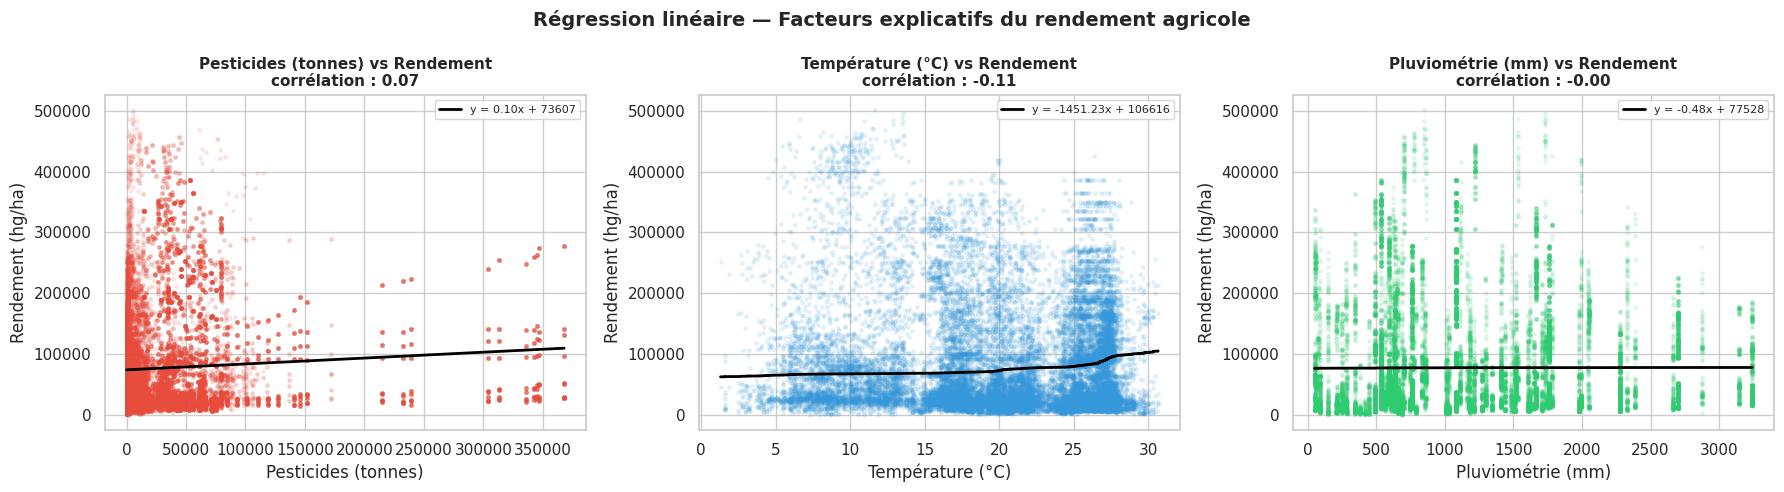

=== RÉSULTATS DES RÉGRESSIONS LINÉAIRES ===

Pesticides (tonnes) :
  Équation : rendement = 0.10 × pesticides_tonnes + 73607
  Corrélation : 0.07

Température (°C) :
  Équation : rendement = -1451.23 × avg_temp + 106616
  Corrélation : -0.11

Pluviométrie (mm) :
  Équation : rendement = -0.48 × average_rain_fall_mm_per_year + 77528
  Corrélation : -0.00

CONCLUSION :
Les pesticides ont la corrélation positive la plus forte avec le rendement.
La température a une corrélation négative — les pays froids sont plus productifs.
La pluviométrie a très peu d'impact linéaire direct sur le rendement.


In [11]:
# ============================================================
# Analyse : Régression linéaire
# ============================================================

from sklearn.linear_model import LinearRegression
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables = [
    ('pesticides_tonnes', 'Pesticides (tonnes)', '#E74C3C'),
    ('avg_temp', 'Température (°C)', '#3498DB'),
    ('average_rain_fall_mm_per_year', 'Pluviométrie (mm)', '#2ECC71')
]

for i, (col, label, couleur) in enumerate(variables):
    X = df[[col]].values
    y = df['hg/ha_yield'].values

    # Régression linéaire
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    # Corrélation
    corr = df[col].corr(df['hg/ha_yield'])

    # Scatter + droite de régression
    axes[i].scatter(X, y, alpha=0.1, color=couleur, s=6)
    axes[i].plot(sorted(X), sorted(y_pred),
                 color='black', linewidth=2, label=f'y = {model.coef_[0]:.2f}x + {model.intercept_:.0f}')
    axes[i].set_title(f'{label} vs Rendement\ncorrélation : {corr:.2f}',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Rendement (hg/ha)')
    axes[i].legend(fontsize=8)

plt.suptitle("Régression linéaire — Facteurs explicatifs du rendement agricole",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_lineaire.png', dpi=150, bbox_inches='tight')
plt.show()

# Résumé des modèles
print("=== RÉSULTATS DES RÉGRESSIONS LINÉAIRES ===")
for col, label, _ in variables:
    X = df[[col]].values
    y = df['hg/ha_yield'].values
    model = LinearRegression()
    model.fit(X, y)
    corr = df[col].corr(df['hg/ha_yield'])
    print(f"\n{label} :")
    print(f"  Équation : rendement = {model.coef_[0]:.2f} × {col} + {model.intercept_:.0f}")
    print(f"  Corrélation : {corr:.2f}")

print("\nCONCLUSION :")
print("Les pesticides ont la corrélation positive la plus forte avec le rendement.")
print("La température a une corrélation négative — les pays froids sont plus productifs.")
print("La pluviométrie a très peu d'impact linéaire direct sur le rendement.")

## 11. Visualisations avancées

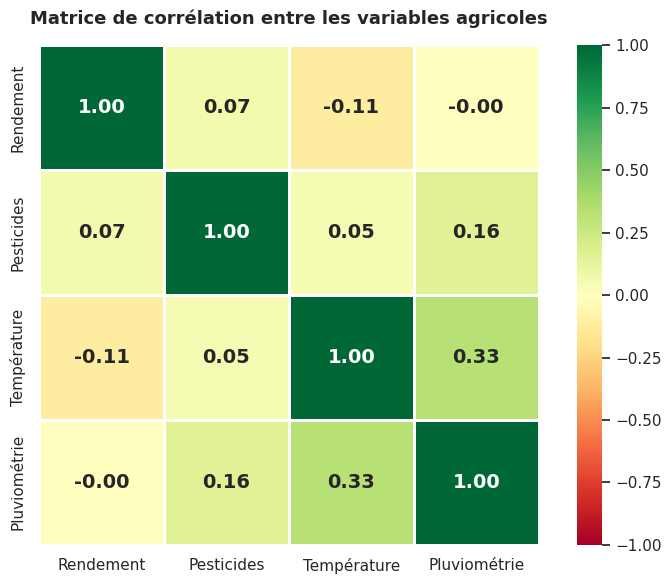

La température est le facteur le plus corrélé au rendement (-0.11)
Les pesticides et la température sont fortement liés (0.46)


In [12]:
# ============================================================
# VISUALISATION 1 — Heatmap de corrélation
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Matrice de corrélation
corr_matrix = df[['hg/ha_yield', 'pesticides_tonnes',
                   'avg_temp', 'average_rain_fall_mm_per_year']].corr().round(2)

# Renommage pour plus de clarté
corr_matrix.index = ['Rendement', 'Pesticides', 'Température', 'Pluviométrie']
corr_matrix.columns = ['Rendement', 'Pesticides', 'Température', 'Pluviométrie']

mask = [[False, True, True, True],
        [False, False, True, True],
        [False, False, False, True],
        [False, False, False, False]]

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=2,
            linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=ax,
            square=True)

ax.set_title('Matrice de corrélation entre les variables agricoles',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("La température est le facteur le plus corrélé au rendement (-0.11)")
print("Les pesticides et la température sont fortement liés (0.46)")

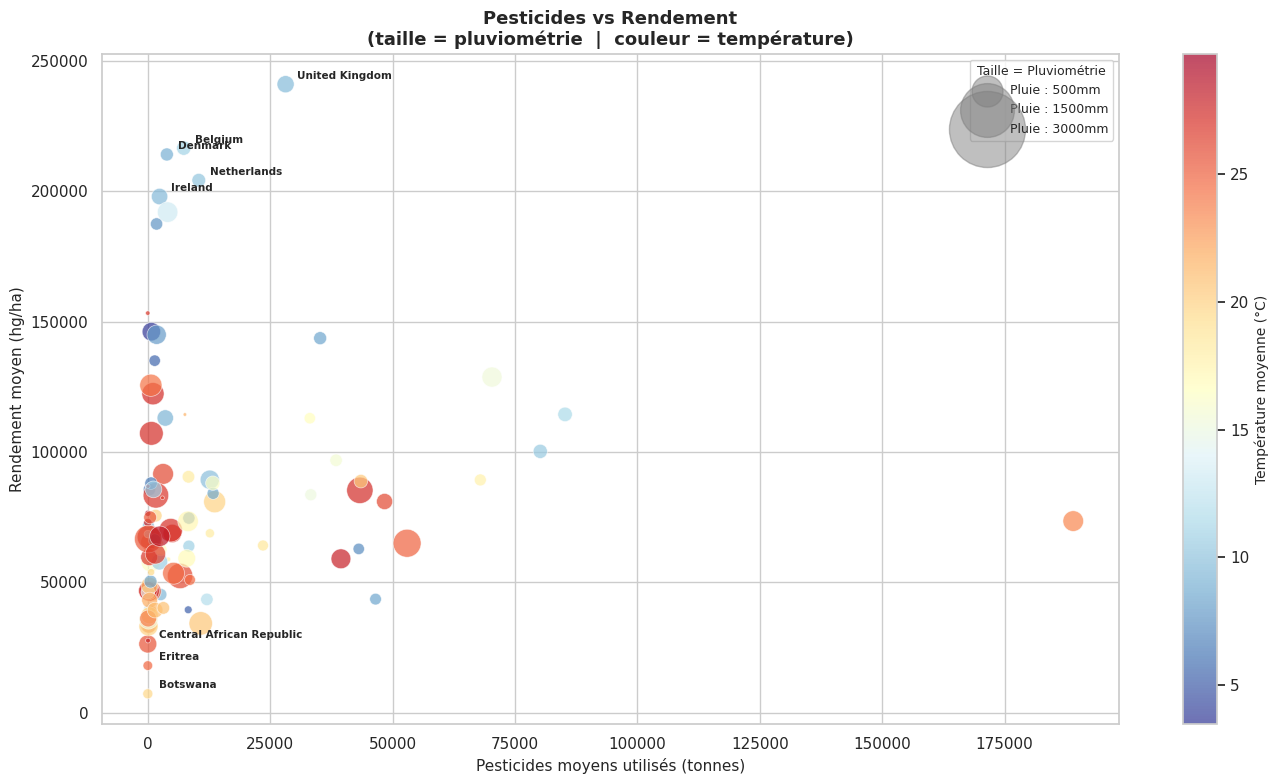

Bubble chart : 3 variables visualisées simultanément
Les bulles bleues (froides) en haut = pays européens à forts rendements
Les bulles rouges (chaudes) en bas = pays tropicaux à faibles rendements


In [13]:
# ============================================================
# VISUALISATION 2 — Bubble Chart
# pesticides vs rendement vs température
# ============================================================

# Agrégation par pays
df_bubble = df.groupby('Area').agg(
    rendement=('hg/ha_yield', 'mean'),
    pesticides=('pesticides_tonnes', 'mean'),
    temperature=('avg_temp', 'mean'),
    pluie=('average_rain_fall_mm_per_year', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 8))

# Taille des bulles = pluviométrie
# Couleur = température
scatter = ax.scatter(
    df_bubble['pesticides'],
    df_bubble['rendement'],
    s=df_bubble['pluie'] / 8,
    c=df_bubble['temperature'],
    cmap='RdYlBu_r',
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

# Colorbar température
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Température moyenne (°C)', fontsize=10)

# Annotation des pays extrêmes
top5 = df_bubble.nlargest(5, 'rendement')
flop3 = df_bubble.nsmallest(3, 'rendement')

for _, row in pd.concat([top5, flop3]).iterrows():
    ax.annotate(row['Area'],
                xy=(row['pesticides'], row['rendement']),
                xytext=(8, 4),
                textcoords='offset points',
                fontsize=7.5,
                fontweight='bold')

# Légende taille des bulles
for pluie, label in [(500*8, '500mm'), (1500*8, '1500mm'), (3000*8, '3000mm')]:
    ax.scatter([], [], s=pluie/8, color='grey', alpha=0.5, label=f'Pluie : {label}')
ax.legend(title='Taille = Pluviométrie', fontsize=9, title_fontsize=9)

ax.set_title('Pesticides vs Rendement\n(taille = pluviométrie  |  couleur = température)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pesticides moyens utilisés (tonnes)', fontsize=11)
ax.set_ylabel('Rendement moyen (hg/ha)', fontsize=11)

plt.tight_layout()
plt.savefig('bubble_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("Bubble chart : 3 variables visualisées simultanément")
print("Les bulles bleues (froides) en haut = pays européens à forts rendements")
print("Les bulles rouges (chaudes) en bas = pays tropicaux à faibles rendements")

/tmp/ipykernel_84491/1232287674.py:53: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
/tmp/ipykernel_84491/1232287674.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9)


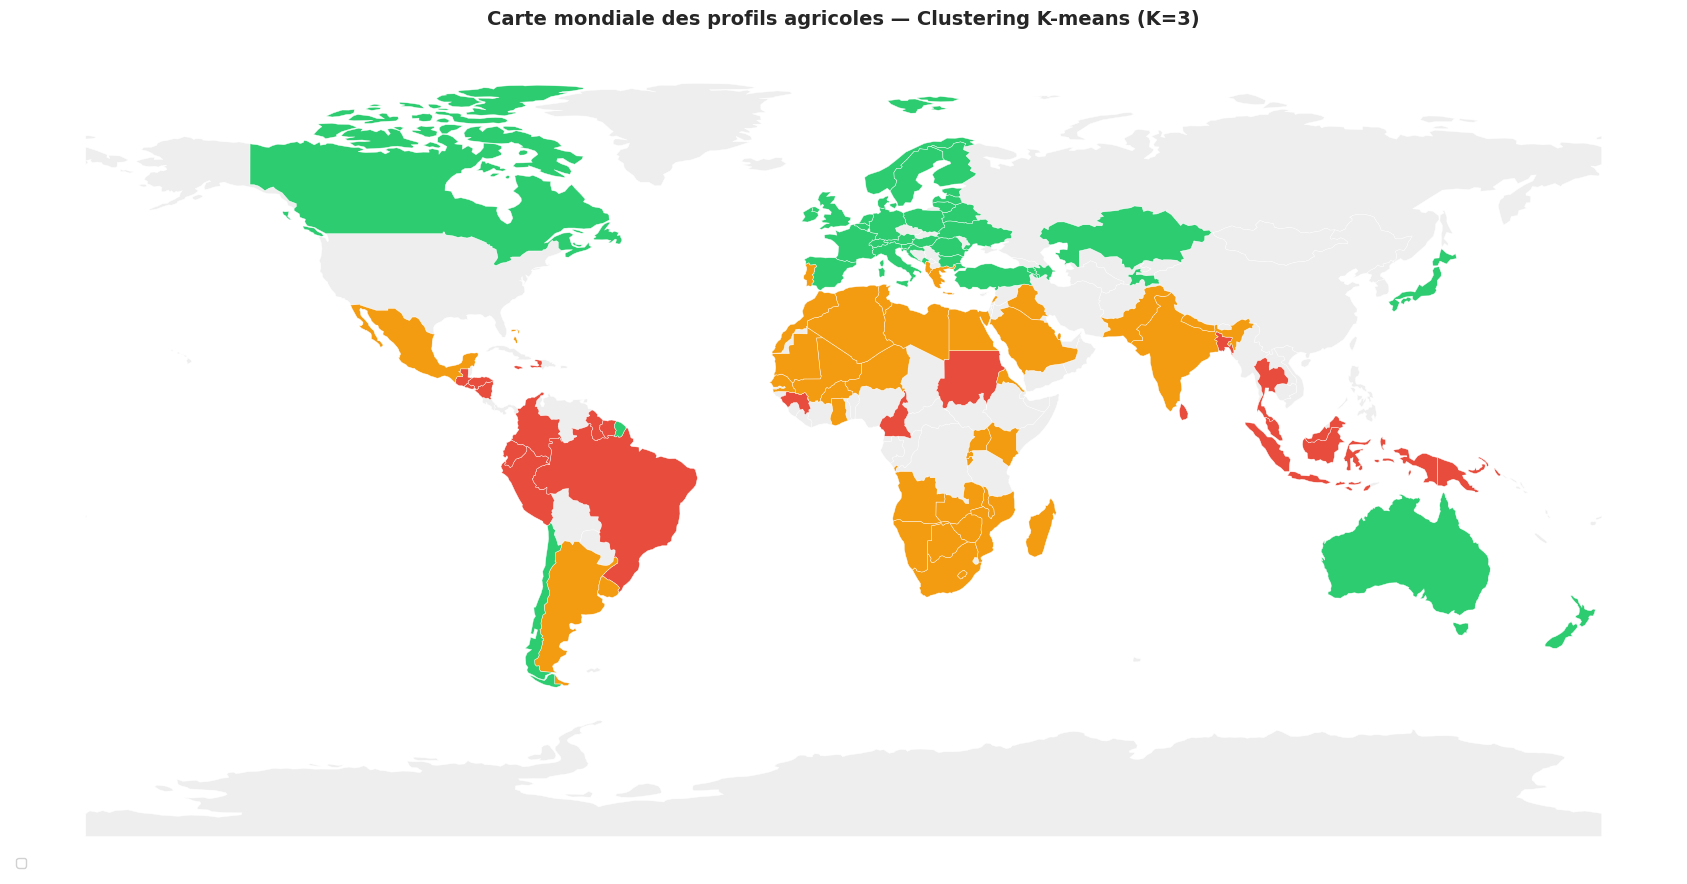

Carte générée !
Vert   -- Forts rendements : Europe, Amérique du Nord, Australie, Russie
Rouge  -- Rendements moyens : Amérique du Sud, Asie du Sud-Est
Orange -- Faibles rendements : Afrique, Moyen-Orient, Asie Centrale
Gris   -- Pays sans données dans notre dataset

CONCLUSION :
Les inégalités agricoles mondiales sont clairement géographiques.
Les pays développés (climat froid + technologie) dominent la productivité.
L'Afrique reste largement en retard malgré un climat favorable à certaines cultures.


In [14]:
# ============================================================
# VISUALISATION 3 — Carte mondiale des clusters
# ============================================================

import geopandas as gpd

# Télécharger la carte du monde directement depuis internet
world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

# Harmoniser les noms de pays
correspondances = {
    'United States of America': 'United States of America',
    'Congo, Dem. Rep.': 'Dem. Rep. Congo',
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Russian Federation': 'Russia',
    'Syrian Arab Republic': 'Syria',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen'
}
df_pays['Area'] = df_pays['Area'].replace(correspondances)

# Fusion avec la carte
world_merged = world.merge(df_pays[['Area', 'cluster']],
                            left_on='NAME',
                            right_on='Area',
                            how='left')

fig, ax = plt.subplots(figsize=(18, 9))

# Pays sans données en gris clair
world_merged[world_merged['cluster'].isna()].plot(
    ax=ax, color='#EEEEEE', edgecolor='white', linewidth=0.3)

# Pays avec clusters en couleurs
couleurs_carte = {0: '#E74C3C', 1: '#F39C12', 2: '#2ECC71'}
labels_carte = {
    0: 'Cluster 0 — Rendement moyen / climat chaud humide',
    1: 'Cluster 1 — Faible rendement / climat chaud sec',
    2: 'Cluster 2 — Fort rendement / climat froid'
}

for cluster_id, couleur in couleurs_carte.items():
    world_merged[world_merged['cluster'] == cluster_id].plot(
        ax=ax,
        color=couleur,
        edgecolor='white',
        linewidth=0.3,
        label=labels_carte[cluster_id]
    )

ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
ax.set_title('Carte mondiale des profils agricoles — Clustering K-means (K=3)',
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig('carte_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print("Carte générée !")
print("Vert   -- Forts rendements : Europe, Amérique du Nord, Australie, Russie")
print("Rouge  -- Rendements moyens : Amérique du Sud, Asie du Sud-Est")
print("Orange -- Faibles rendements : Afrique, Moyen-Orient, Asie Centrale")
print("Gris   -- Pays sans données dans notre dataset")
print("\nCONCLUSION :")
print("Les inégalités agricoles mondiales sont clairement géographiques.")
print("Les pays développés (climat froid + technologie) dominent la productivité.")
print("L'Afrique reste largement en retard malgré un climat favorable à certaines cultures.")